<a href="https://colab.research.google.com/github/Bhanu-Jakka/ML_Project/blob/main/EDA_IPL_MatchPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Load the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Load the data
matches = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')

In [ ]:
#Look at the data
print(matches.shape)
print(matches.head())

(1095, 20)
       id   season        city        date match_type player_of_match  \
0  335982  2007/08   Bangalore  2008-04-18     League     BB McCullum   
1  335983  2007/08  Chandigarh  2008-04-19     League      MEK Hussey   
2  335984  2007/08       Delhi  2008-04-19     League     MF Maharoof   
3  335985  2007/08      Mumbai  2008-04-20     League      MV Boucher   
4  335986  2007/08     Kolkata  2008-04-20     League       DJ Hussey   

                                        venue                        team1  \
0                       M Chinnaswamy Stadium  Royal Challengers Bangalore   
1  Punjab Cricket Association Stadium, Mohali              Kings XI Punjab   
2                            Feroz Shah Kotla             Delhi Daredevils   
3                            Wankhede Stadium               Mumbai Indians   
4                                Eden Gardens        Kolkata Knight Riders   

                         team2                  toss_winner toss_decision  \
0   

In [ ]:
#Look at the data
print(deliveries.shape)
print(deliveries.head())

(260920, 17)
   match_id  inning           batting_team                 bowling_team  over  \
0    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
1    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
2    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
3    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
4    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   

   ball       batter   bowler  non_striker  batsman_runs  extra_runs  \
0     1   SC Ganguly  P Kumar  BB McCullum             0           1   
1     2  BB McCullum  P Kumar   SC Ganguly             0           0   
2     3  BB McCullum  P Kumar   SC Ganguly             0           1   
3     4  BB McCullum  P Kumar   SC Ganguly             0           0   
4     5  BB McCullum  P Kumar   SC Ganguly             0           0   

   total_runs extras_type  is_wicket player_dismissed dismissal_kin

In [ ]:
#Check for missing data
print(matches.isnull().sum())

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64


In [ ]:
#Clean up team names
matches['team1'] = matches['team1'].replace({
    'Delhi Daredevils': 'Delhi Capitals',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Kings XI Punjab': 'Punjab Kings'
})
matches['team2'] = matches['team2'].replace({
    'Delhi Daredevils': 'Delhi Capitals',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Kings XI Punjab': 'Punjab Kings'
})
matches['winner'] = matches['winner'].replace({
    'Delhi Daredevils': 'Delhi Capitals',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Kings XI Punjab': 'Punjab Kings'
})

In [ ]:
#See which teams won the most matches
matches['winner'].value_counts()

,count
winner,
Mumbai Indians,144
Chennai Super Kings,138
Kolkata Knight Riders,131
Sunrisers Hyderabad,117
Royal Challengers Bangalore,116
Delhi Capitals,115
Punjab Kings,112
Rajasthan Royals,112
Gujarat Titans,28


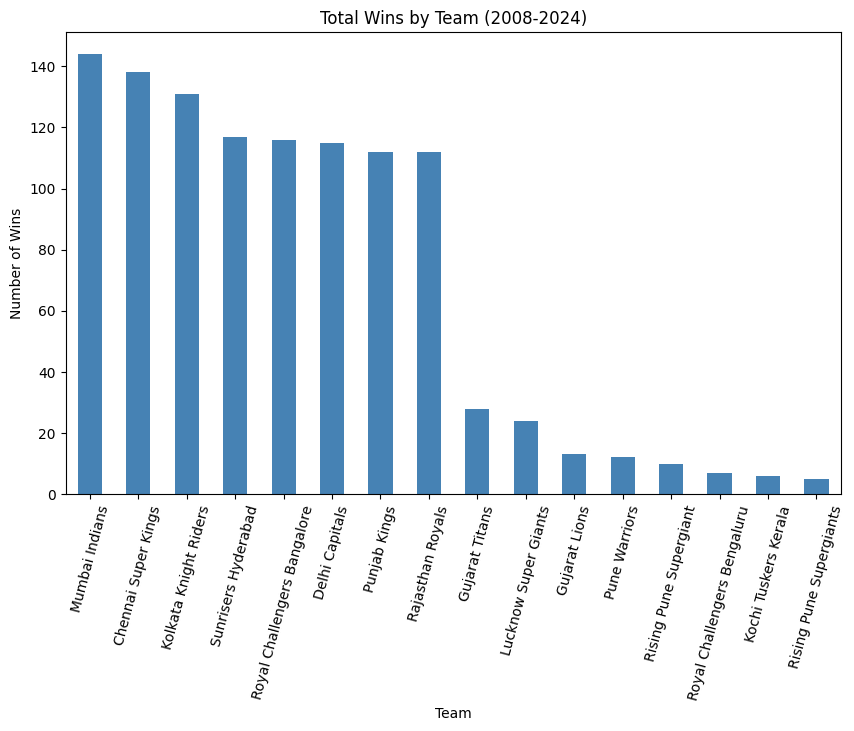

In [ ]:
#Plot it as a bar chart
plt.figure(figsize=(10,6))
matches['winner'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Total Wins by Team (2008-2024)')
plt.xlabel('Team')
plt.ylabel('Number of Wins')
plt.xticks(rotation=75)
plt.show()

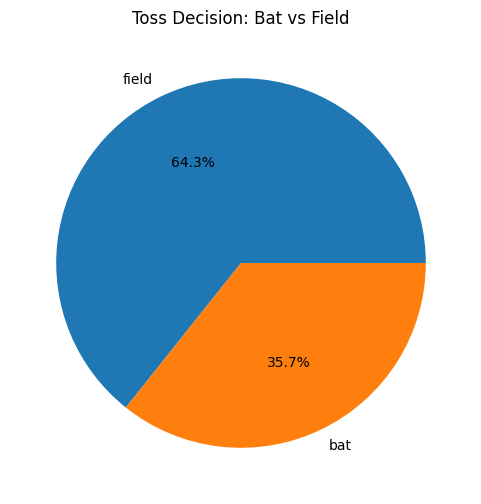

In [ ]:
#Toss decision split
matches['toss_decision'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))
plt.title('Toss Decision: Bat vs Field')
plt.ylabel('')
plt.show()

In [ ]:
#Does winning the toss mean winning the match?
matches['toss_winner_match_winner'] = matches['toss_winner'] == matches['winner']
matches['toss_winner_match_winner'].value_counts(normalize=True) * 100

,proportion
toss_winner_match_winner,
False,57.625571
True,42.374429


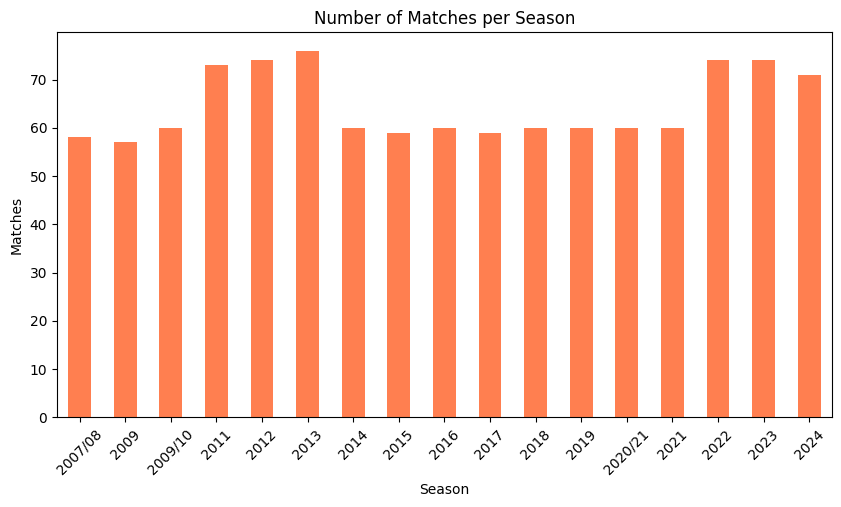

In [ ]:
#Matches per season
plt.figure(figsize=(10,5))
matches['season'].value_counts().sort_index().plot(kind='bar', color='coral')
plt.title('Number of Matches per Season')
plt.xlabel('Season')
plt.ylabel('Matches')
plt.xticks(rotation=45)
plt.show()

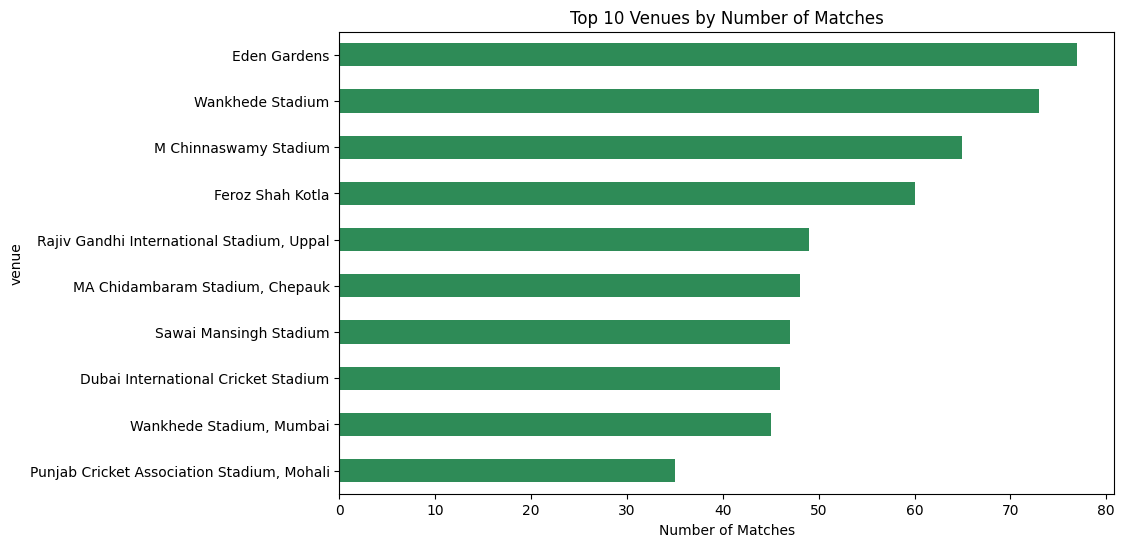

In [ ]:
#Top 10 venues by number of matches
plt.figure(figsize=(10,6))
matches['venue'].value_counts().head(10).plot(kind='barh', color='seagreen')
plt.title('Top 10 Venues by Number of Matches')
plt.xlabel('Number of Matches')
plt.gca().invert_yaxis()
plt.show()

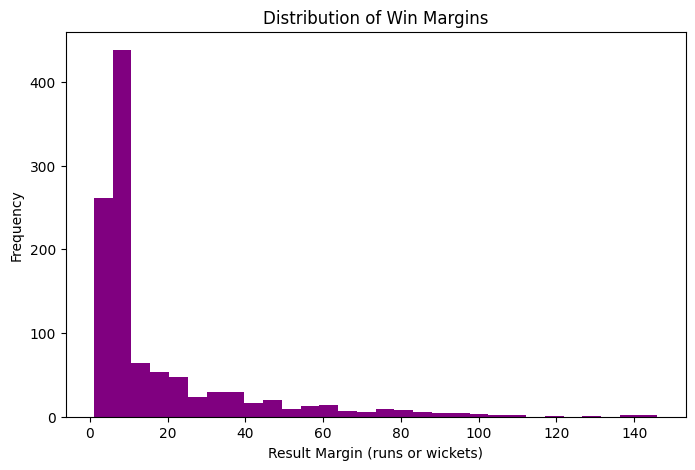

In [ ]:
#Win margin distribution
plt.figure(figsize=(8,5))
matches['result_margin'].dropna().plot(kind='hist', bins=30, color='purple')
plt.title('Distribution of Win Margins')
plt.xlabel('Result Margin (runs or wickets)')
plt.show()

In [ ]:
#Home vs away — check if venue city matches team name pattern
matches['city'].value_counts().head(15)

,count
city,
Mumbai,173
Kolkata,93
Delhi,90
Chennai,85
Hyderabad,77
Bangalore,65
Chandigarh,61
Jaipur,57
Pune,51


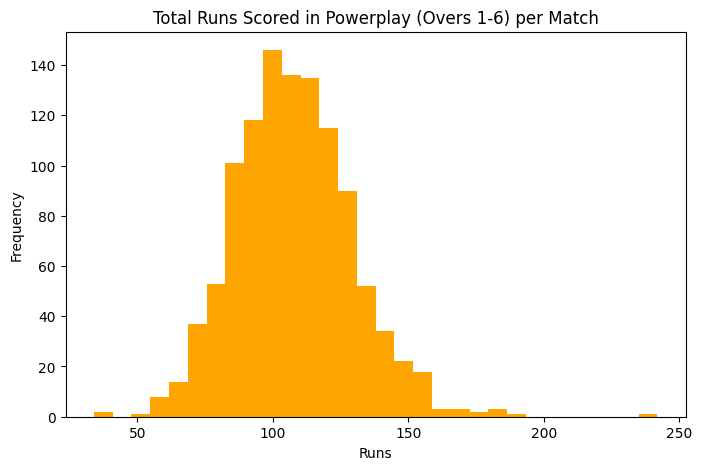

In [ ]:
#Runs per over from deliveries.csv — powerplay analysis
powerplay = deliveries[deliveries['over'] <= 6]
powerplay_runs = powerplay.groupby('match_id')['total_runs'].sum()
powerplay_runs.plot(kind='hist', bins=30, color='orange', figsize=(8,5))
plt.title('Total Runs Scored in Powerplay (Overs 1-6) per Match')
plt.xlabel('Runs')
plt.show()

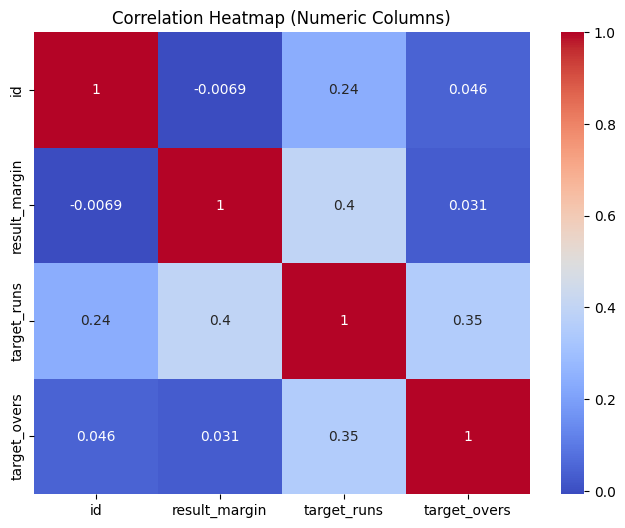

In [ ]:
#Correlation heatmap
numeric_cols = matches.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(8,6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap (Numeric Columns)')
plt.show()